In [101]:
import pandas as pd

df = pd.read_csv("titanic.csv")
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [102]:
print(df.shape)
print(df.columns)
print(df["Survived"].value_counts())

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')
Survived
0    549
1    342
Name: count, dtype: int64


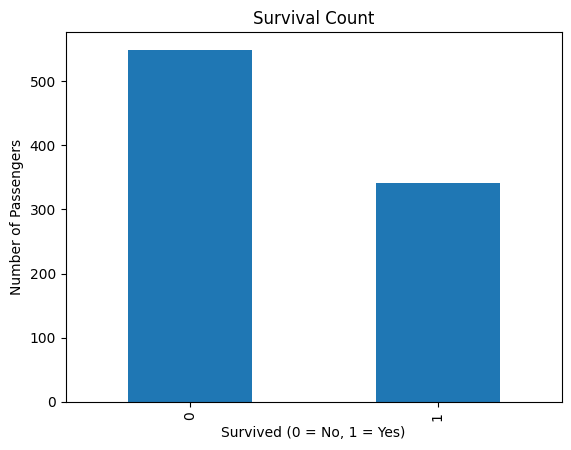

In [103]:
import matplotlib.pyplot as plt

df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

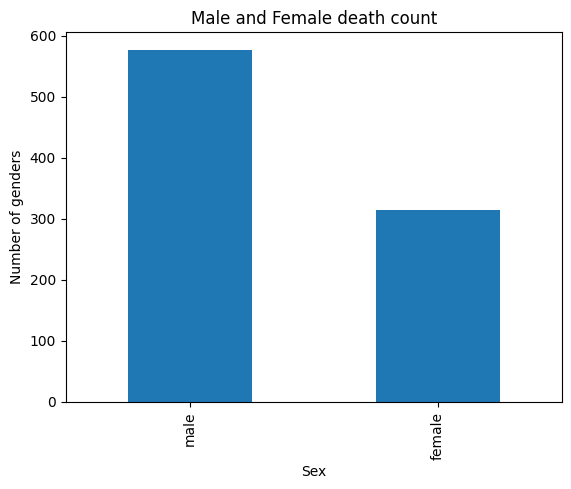

In [104]:
df["Sex"].value_counts().plot(kind="bar")
plt.title("Male and Female death count")
plt.ylabel("Number of genders")
plt.show()

In [105]:
print(df[(df["Sex"] == "male") & (df["Survived"] == 0)].shape[0],"Mens survived")
print(df[(df["Sex"] == "female") & (df["Survived"] == 0)].shape[0],"Womens survived")

468 Mens survived
81 Womens survived


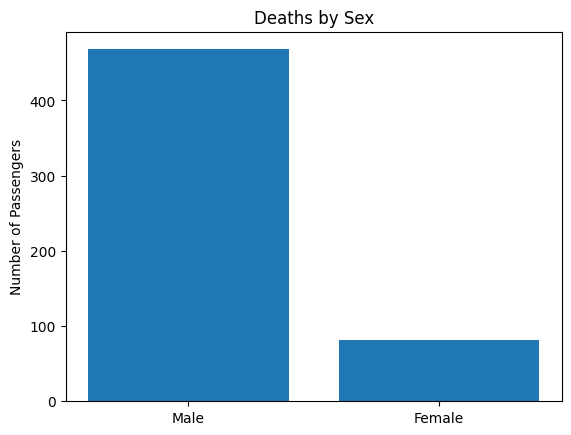

In [106]:
male_deaths = df[(df["Sex"] == "male") & (df["Survived"] == 0)].shape[0]
female_deaths = df[(df["Sex"] == "female") & (df["Survived"] == 0)].shape[0]

plt.bar(["Male", "Female"], [male_deaths, female_deaths])
plt.title("Deaths by Sex")
plt.ylabel("Number of Passengers")
plt.show()

In [107]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


DATA CLEANING

In [108]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.drop(columns=["Cabin"])
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [109]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [110]:
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

In [111]:
df["Sex"].head(10)

0    0
1    1
2    1
3    1
4    0
5    0
6    0
7    0
8    1
9    1
Name: Sex, dtype: int64

This line converts the categorical Embarked column into numerical columns using one-hot encoding.

The original Embarked column contains text values (S, C, and Q), which machine learning models cannot process directly. pd.get_dummies() creates separate binary (0/1) columns for each category.

The parameter drop_first=True removes one of the generated columns to avoid redundant information and reduce multicollinearity. Since the remaining columns already contain enough information to identify the missing category, keeping all of them is unnecessary.

In [112]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [113]:
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = df[features]
y = df["Survived"]

In [114]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(712, 6) (179, 6)


Training Model

In [115]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")

Training accuracy: 88.62%
Test accuracy: 81.56%


In [116]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Individual fold scores:", scores)
print(f"Average accuracy: {scores.mean():.2%}")
print(f"Standard deviation: {scores.std():.2%}")

Individual fold scores: [0.83240223 0.83146067 0.83146067 0.82022472 0.83707865]
Average accuracy: 83.05%
Standard deviation: 0.56%


Evaluate accuracy

In [117]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print(f"Training accuracy: {train_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")

Training accuracy: 88.62%
Test accuracy: 81.56%


In [118]:
from sklearn.metrics import accuracy_score

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 81.56%


Predict a custom person

In [122]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

  Feature  Importance
1     Sex    0.612122
0  Pclass    0.214299
3   SibSp    0.064948
5    Fare    0.046284
2     Age    0.042627
4   Parch    0.019721


In [120]:
import pandas as pd

new_person = pd.DataFrame({
    "Pclass": [1],
    "Sex": [1],
    "Age": [38],
    "SibSp": [1],
    "Parch": [0],
    "Fare": [71.2833]
})

prediction = model.predict(new_person)
probability = model.predict_proba(new_person)

print("Survived" if prediction[0] == 1 else "Did not survive")
print(f"Probability of survival: {probability[0][1]:.2%}")

Survived
Probability of survival: 96.44%
